# Hybrid VQC Model Evaluation

This notebook evaluates the trained **Hybrid VQC** model on the test set.
It generates performance metrics and visualizations including Confusion Matrix and ROC Curves.

In [2]:
import pandas as pd
import numpy as np
import os
import torch
import torch.nn as nn
import pennylane as qml
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import pickle

# Set Style
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = [10, 8]

In [3]:
# --- Configuration --- 
# Must match training config
DATASET_PATH = r'Datasets/processed_data.csv'
MODEL_PATH = r'trained_model/hybrid_vqc_ids2017.pth'
BATCH_SIZE = 32
N_QUBITS = 4
N_LAYERS = 2
SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [4]:
# --- Data Loading ---
print("Loading dataset...")
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"Dataset not found at {DATASET_PATH}")

df = pd.read_csv(DATASET_PATH)
X = df.drop(columns=['label']).values
y = df['label'].values

num_classes = len(np.unique(y))
print(f"Number of classes: {num_classes}")

# Train/Test Split (Same seed as training to ensure correct test set)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

if num_classes == 2:
    y_test_tensor = y_test_tensor.float().unsqueeze(1)
    print("Binary Classification mode")
else:
    print("Multiclass Classification mode")

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Test samples: {len(X_test)}")

Loading dataset...
Number of classes: 14
Multiclass Classification mode
Test samples: 168110


In [5]:
# --- Model Architecture (Must match Training) ---
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch")
def vqc_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS))
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

class HybridVQC(nn.Module):
    def __init__(self, input_dim, n_qubits, n_layers, output_dim):
        super(HybridVQC, self).__init__()
        self.n_qubits = n_qubits
        self.cl_layer1 = nn.Linear(input_dim, 64)
        self.cl_layer2 = nn.Linear(64, n_qubits)
        weight_shapes = {"weights": (n_layers, n_qubits, 3)}
        self.vqc = qml.qnn.TorchLayer(vqc_circuit, weight_shapes)
        self.cl_layer3 = nn.Linear(n_qubits, output_dim)
        
    def forward(self, x):
        x = torch.relu(self.cl_layer1(x))
        x = torch.tanh(self.cl_layer2(x)) * np.pi 
        x = self.vqc(x)
        x = self.cl_layer3(x)
        return x

# Initialize Model
output_dim = 1 if num_classes == 2 else num_classes
model = HybridVQC(X_test.shape[1], N_QUBITS, N_LAYERS, output_dim).to(device)

# Load Weights
if os.path.exists(MODEL_PATH):
    print(f"Loading model weights from {MODEL_PATH}...")
    model.load_state_dict(torch.load(MODEL_PATH))
else:
    # Fallback to checkpoint if main model not found
    ckpt_path = 'checkpoints/checkpoint_ids2017_vqc.pth'
    if os.path.exists(ckpt_path):
        print(f"Main model not found. Loading checkpoint from {ckpt_path}...")
        checkpoint = torch.load(ckpt_path)
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        raise FileNotFoundError("No trained model or checkpoint found!")

model.eval()

Loading model weights from trained_model/hybrid_vqc_ids2017.pth...


HybridVQC(
  (cl_layer1): Linear(in_features=116, out_features=64, bias=True)
  (cl_layer2): Linear(in_features=64, out_features=4, bias=True)
  (vqc): <Quantum Torch Layer: func=vqc_circuit>
  (cl_layer3): Linear(in_features=4, out_features=14, bias=True)
)

In [6]:
# --- Evaluation Loop ---
all_preds = []
all_probs = []
all_labels = []

print("Evaluating on Test Set...")
with torch.no_grad():
    for X_batch, y_batch in tqdm(test_loader):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        
        if num_classes == 2:
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).long()
        else:
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(logits, dim=1)
            
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

Evaluating on Test Set...


100%|██████████| 5254/5254 [01:17<00:00, 67.80it/s]


In [7]:
# --- Classification Report ---
print("\nClassification Report:")
print(classification_report(all_labels, all_preds))


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.93     99980
           1       0.71      0.17      0.27      1086
           2       0.99      1.00      1.00     19159
           3       0.94      0.51      0.66      1684
           4       0.93      0.63      0.75     19920
           5       0.00      0.00      0.00      1388
           6       0.93      0.16      0.27      1027
           7       0.64      0.66      0.65      1906
           9       0.97      0.98      0.97     19967
          10       0.58      0.32      0.41      1156
          11       0.00      0.00      0.00       558
          12       0.00      0.00      0.00         8
          13       0.00      0.00      0.00       271

    accuracy                           0.91    168110
   macro avg       0.58      0.42      0.46    168110
weighted avg       0.90      0.91      0.89    168110



d:\M tech\Final Project\APRE\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\M tech\Final Project\APRE\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\M tech\Final Project\APRE\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

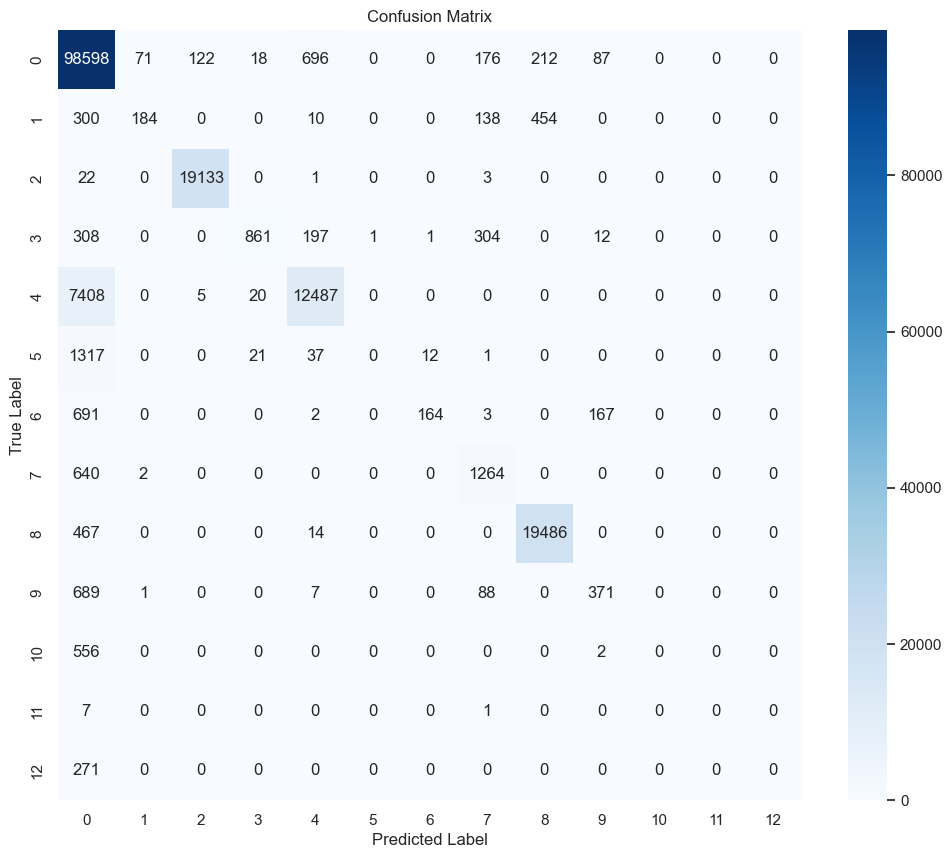

In [8]:
# --- Confusion Matrix Heatmap ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

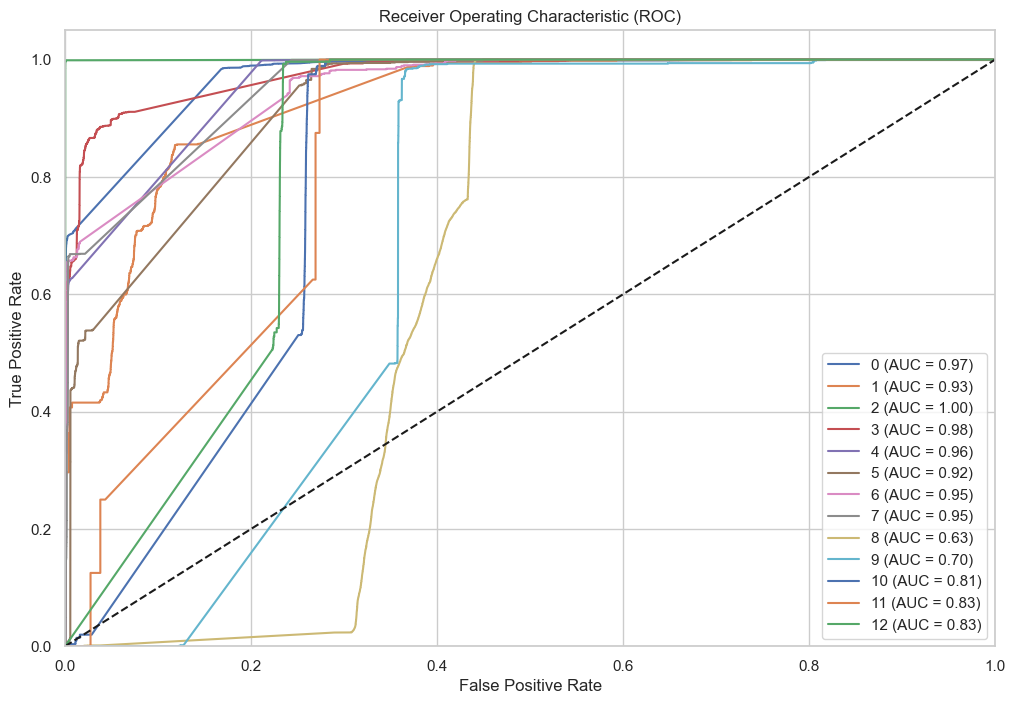

In [9]:
# --- ROC Curve ---
# Try to load class names if available
try:
    import pickle
    le = pickle.load(open('label_encoder.pkl', 'rb'))
    class_names = le.classes_
    # Handle mismatch if encoder has different classes than test set
    if len(class_names) != num_classes:
         # Fallback if label encoder doesn't match current data subset
         class_names = [str(i) for i in range(num_classes)]
except:
    class_names = [str(i) for i in range(num_classes)]

plt.figure(figsize=(12, 8))

if num_classes == 2:
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
else:
    # One-vs-Rest ROC for Multiclass
    lb = LabelBinarizer()
    y_test_bin = lb.fit_transform(all_labels)
    
    for i in range(num_classes):
        # Check if class exists in test set
        if i < y_test_bin.shape[1]:
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
            roc_auc = auc(fpr, tpr)
            label_name = class_names[i] if i < len(class_names) else f'Class {i}'
            plt.plot(fpr, tpr, label=f'{label_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()